<a href="https://colab.research.google.com/github/8946-art/Boosting_eVISA_Business-Application/blob/main/NBFC%20Loan%20Default.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **NBFC Loan Default**

## **by Brian Kwame Renner Sadiku**



* Contents
* Overview of Dataset
* Exploratory Data Analysis
* Data Preparation
* Model Building
* Cross Validation Scores
* XGBoost Classifier
* Bagging Classifier
* Decision Tree Classifier
* Stacking Classifier
* Test Set Prediction


## **Background**

A non-banking financial institution (NBFI) or non-bank financial company (NBFC) is a Financial Institution that does not have a full banking license or is not supervised by a national or international banking regulatory agency. NBFC facilitates bank-related financial services, such as investment, risk pooling, contractual savings, and market brokering. The following is the story of a challenge faced by DHDL Ltd. (Name Changed), an NBFC in India. In recent times, the company is struggling to mark profits due to an increase in Loan Defaults. The company aims to determine the relative importance of each parameter with regards to their contribution as to whether a loan is going to default or not. Provided is a sample that contains the data of 90,000 + clients who have taken a loan from the company in the past with the information on whether the loan defaulted.

## **Objective**

The objective of this exercise is to understand which parameters play an important role in determining whether a client will default on the loan payment.

## **Data Dictionary**


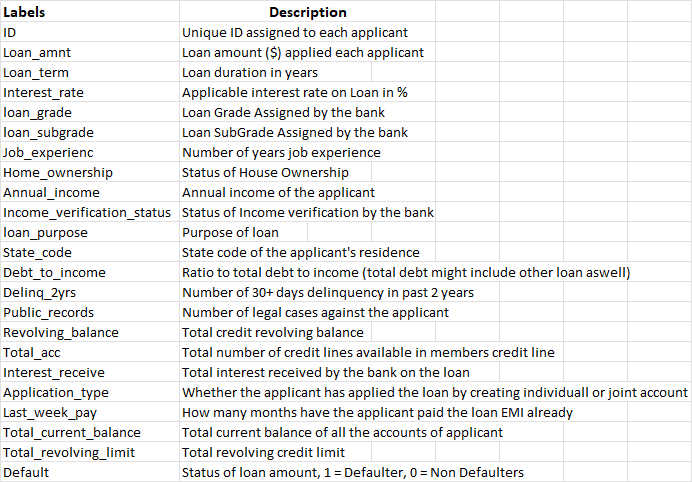


## **Overview of Dataset**

## Import Libraries

In [7]:
import warnings
warnings.filterwarnings("ignore")

import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    make_scorer
)
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    StackingClassifier
)
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV
)

# to suppress scientific notations
pd.set_option('display.float_format', lambda x: '%.3f' % x)
%matplotlib inline
sns.set()

## **Load dataset**

In [8]:
data = pd.read_csv('/content/Train_set..csv')
df = data.copy()

In [9]:
df.shape

(93174, 23)

In [10]:
pd.concat([df.head(5), df.sample(5), df.tail(5)])

,ID,loan_amnt,loan_term,interest_rate,loan_grade,loan_subgrade,job_experience,home_ownership,annual_income,income_verification_status,...,delinq_2yrs,public_records,revolving_balance,total_acc,interest_receive,application_type,last_week_pay,total_current_balance,total_revolving_limit,default
0,72199369,9000,3 years,9.170,B,B2,<5 Years,OWN,85000.000,Not Verified,...,0.000,0.000,39519,20.000,59.600,INDIVIDUAL,4.000,95493.000,84100.000,0
1,14257956,18000,3 years,13.650,C,C1,<5 Years,OWN,64000.000,Verified,...,0.000,1.000,9783,24.000,3348.250,INDIVIDUAL,95.000,185433.000,13500.000,0
2,66216451,16000,3 years,7.260,A,A4,<5 Years,MORTGAGE,150000.000,Source Verified,...,2.000,0.000,13641,27.000,276.690,INDIVIDUAL,13.000,180519.000,19300.000,0
3,46974169,25000,3 years,13.990,C,C4,NaN,MORTGAGE,59800.000,Verified,...,0.000,0.000,35020,35.000,1106.720,INDIVIDUAL,17.000,183208.000,55400.000,0
4,46725961,17000,3 years,6.390,A,A2,10+ years,MORTGAGE,72000.000,Source Verified,...,0.000,0.000,23990,26.000,725.290,INDIVIDUAL,39.000,23990.000,81300.000,0
14267,12606841,14000,3 years,12.490,B,B5,<5 Years,MORTGAGE,93216.000,Not Verified,...,0.000,1.000,7673,41.000,2079.550,INDIVIDUAL,78.000,48947.000,28130.000,0
92460,67832586,15000,3 years,12.690,C,C2,<5 Years,RENT,120000.000,Source Verified,...,1.000,0.000,10066,17.000,292.460,INDIVIDUAL,13.000,112338.000,15200.000,0
53264,67737525,15000,3 years,5.320,A,A1,<5 Years,MORTGAGE,95000.000,Not Verified,...,0.000,0.000,14017,24.000,126.860,INDIVIDUAL,9.000,239934.000,51200.000,0
26196,53326232,2000,3 years,13.330,C,C3,10+ years,RENT,52000.000,Not Verified,...,1.000,0.000,4425,37.000,19.260,INDIVIDUAL,4.000,54820.000,11600.000,1
1549,7829745,21100,3 years,12.350,B,B4,6-10 years,RENT,60000.000,Verified,...,0.000,1.000,8088,9.000,3014.130,INDIVIDUAL,78.000,16717.000,15100.000,1


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93174 entries, 0 to 93173
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          93174 non-null  int64  
 1   loan_amnt                   93174 non-null  int64  
 2   loan_term                   93174 non-null  object 
 3   interest_rate               93174 non-null  float64
 4   loan_grade                  93174 non-null  object 
 5   loan_subgrade               93174 non-null  object 
 6   job_experience              88472 non-null  object 
 7   home_ownership              93174 non-null  object 
 8   annual_income               93173 non-null  float64
 9   income_verification_status  93174 non-null  object 
 10  loan_purpose                93174 non-null  object 
 11  state_code                  93174 non-null  object 
 12  debt_to_income              93174 non-null  float64
 13  delinq_2yrs                 931

In [12]:
display(df.describe(include='all').T)
display(df.describe(include='float').T)
df.describe(include='object').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,93174.000,NaN,NaN,NaN,35050211.389,24149262.074,70735.000,10859832.500,37107507.000,58598949.500,73519746.000
loan_amnt,93174.000,NaN,NaN,NaN,14733.861,8428.185,500.000,8000.000,13000.000,20000.000,35000.000
loan_term,93174,2,3 years,65211,NaN,NaN,NaN,NaN,NaN,NaN,NaN
interest_rate,93174.000,NaN,NaN,NaN,13.233,4.369,5.320,9.990,12.990,16.200,28.990
loan_grade,93174,7,B,26865,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_subgrade,93174,35,B4,5879,NaN,NaN,NaN,NaN,NaN,NaN,NaN
job_experience,88472,3,<5 Years,40610,NaN,NaN,NaN,NaN,NaN,NaN,NaN
home_ownership,93174,5,MORTGAGE,46445,NaN,NaN,NaN,NaN,NaN,NaN,NaN
annual_income,93173.000,NaN,NaN,NaN,75028.259,69454.784,1200.000,45000.000,64000.000,90000.000,9500000.000
income_verification_status,93174,3,Source Verified,34487,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,count,mean,std,min,25%,50%,75%,max
interest_rate,93174.000,13.233,4.369,5.320,9.990,12.990,16.200,28.990
annual_income,93173.000,75028.259,69454.784,1200.000,45000.000,64000.000,90000.000,9500000.000
debt_to_income,93174.000,18.128,8.563,0.000,11.930,17.640,23.890,672.520
delinq_2yrs,93172.000,0.317,0.881,0.000,0.000,0.000,0.000,22.000
public_records,93172.000,0.196,0.581,0.000,0.000,0.000,0.000,49.000
total_acc,93172.000,25.249,11.855,1.000,17.000,24.000,32.000,119.000
interest_receive,93174.000,1747.264,2088.236,0.000,439.880,1070.755,2219.613,23172.310
last_week_pay,91250.000,58.155,44.327,0.000,22.000,48.000,83.000,291.000
total_current_balance,85788.000,139252.923,157686.791,0.000,29642.000,79363.500,207160.000,8000078.000
total_revolving_limit,85788.000,32085.903,47052.515,0.000,14000.000,23700.000,39700.000,9999999.000


,count,unique,top,freq
loan_term,93174,2,3 years,65211
loan_grade,93174,7,B,26865
loan_subgrade,93174,35,B4,5879
job_experience,88472,3,<5 Years,40610
home_ownership,93174,5,MORTGAGE,46445
income_verification_status,93174,3,Source Verified,34487
loan_purpose,93174,4,debt_consolidation,55241
state_code,93174,50,CA,13744
application_type,93174,2,INDIVIDUAL,93118


In [13]:
try:
    df.drop(['ID'], axis=1, inplace=True)
except:
    print("ID column already dropped")
df.columns

Index(['loan_amnt', 'loan_term', 'interest_rate', 'loan_grade',
       'loan_subgrade', 'job_experience', 'home_ownership', 'annual_income',
       'income_verification_status', 'loan_purpose', 'state_code',
       'debt_to_income', 'delinq_2yrs', 'public_records', 'revolving_balance',
       'total_acc', 'interest_receive', 'application_type', 'last_week_pay',
       'total_current_balance', 'total_revolving_limit', 'default'],
      dtype='object')

In [14]:
df.isnull().sum().sort_values(ascending=False)

,0
total_revolving_limit,7386
total_current_balance,7386
job_experience,4702
last_week_pay,1924
delinq_2yrs,2
total_acc,2
public_records,2
annual_income,1
loan_subgrade,0
loan_term,0


In [15]:
df.isnull().sum()

,0
loan_amnt,0
loan_term,0
interest_rate,0
loan_grade,0
loan_subgrade,0
job_experience,4702
home_ownership,0
annual_income,1
income_verification_status,0
loan_purpose,0


In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
cat_cols = df.select_dtypes(include='object').columns
df[cat_cols] = df[cat_cols].astype('category')
df.select_dtypes(include='category').columns

Index(['loan_term', 'loan_grade', 'loan_subgrade', 'job_experience',
       'home_ownership', 'income_verification_status', 'loan_purpose',
       'state_code', 'application_type'],
      dtype='object')

In [18]:
for i in df.select_dtypes(include=['category']).columns:
    print('Unique values in', i, 'are :')
    print(df[i].value_counts(dropna=False))
    print('*'*50)

Unique values in loan_term are :
loan_term
3 years    65211
5 years    27963
Name: count, dtype: int64
**************************************************
Unique values in loan_grade are :
loan_grade
B    26865
C    25787
A    15534
D    14715
E     7378
F     2344
G      551
Name: count, dtype: int64
**************************************************
Unique values in loan_subgrade are :
loan_subgrade
B4    5879
B3    5879
C2    5479
C1    5443
C3    5270
C4    5182
B2    5169
B5    5095
B1    4843
A5    4723
C5    4413
D1    3716
A4    3631
D2    3239
D3    2759
D4    2717
A3    2450
A1    2377
A2    2353
D5    2284
E1    1924
E2    1736
E3    1513
E4    1228
E5     977
F1     745
F2     545
F3     465
F4     355
F5     234
G1     174
G2     146
G3     105
G5      66
G4      60
Name: count, dtype: int64
**************************************************
Unique values in job_experience are :
job_experience
<5 Years      40610
10+ years     30362
6-10 years    17500
NaN            4702
N

## Exploratory Data Analysis

## Univariate Analysis

In [19]:
def histogram_boxplot(feature, figsize=(15, 7), bins=None):
    """
    Boxplot and histogram combined
    feature: 1-d feature array
    figsize: size of fig (default (15,10))
    bins: number of bins (default None / auto)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(nrows = 2, # Number of rows of the subplot grid= 2
                                           sharex = True, # x-axis will be shared among all subplots
                                           gridspec_kw = {"height_ratios": (.25, .75)},
                                           figsize = figsize
                                           ) # creating the 2 subplots

    sns.boxplot(feature, ax=ax_box2, showmeans=True, color='yellow') # boxplot will be created and a star will indicate the mean value of the column
    sns.distplot(feature, kde=True, ax=ax_hist2, bins=bins) if bins else sns.distplot(feature, kde=True, ax=ax_hist2) # For histogram
    ax_hist2.axvline(np.mean(feature), color='green', linestyle='--') # Add mean to the histogram
    ax_hist2.axvline(np.median(feature), color='blue', linestyle='-');# Add median to the histogram

In [20]:
def perc_on_bar(feature):
    '''
    plot
    feature: categorical feature
    the function won't work if a column is passed in hue parameter
    '''
    #Creating a countplot for the feature
    sns.set(rc={'figure.figsize':(15,7)})
    ax=sns.countplot(x=feature, data=data, palette='mako')

    total = len(feature) # length of the column
    for p in ax.patches:
        # percentage of each class of the category
        percentage = 100 * p.get_height()/total
        percentage_label = f"{percentage:.1f}%"
        x = p.get_x() + p.get_width() / 2 - 0.05 # width of the plot
        y = p.get_y() + p.get_height()           # hieght of the plot
        ax.annotate(percentage_label, (x, y), size = 12) # annotate the percantage

    plt.show() # show the plot

In [21]:
### Function to plot distributions and Boxplots of customers
def target_plot(x, target='default'):
    '''
    plot
    feature: categorical feature
    the function won't work if a column is passed in hue parameter
    '''
    fig,axs = plt.subplots(2, 2, figsize=(12,10))
    axs[0, 0].set_title('Distribution of an default')
    sns.distplot(data[(data[target] == 1)][x], ax=axs[0,0], color='teal')
    axs[0, 1].set_title('Distribution of an non-default')
    sns.distplot(data[(data[target] == 0)][x], ax=axs[0,1], color='orange')

    axs[1,0].set_title('Boxplot w.r.t default')
    sns.boxplot(data[target],data[x], ax=axs[1,0],palette='gist_rainbow')
    axs[1,1].set_title('Boxplot w.r.t non-default - Without outliers')
    sns.boxplot(data[target],data[x],ax=axs[1,1],showfliers=False,palette='gist_rainbow')
    plt.tight_layout()
    plt.show()

In [22]:
df.select_dtypes(include='integer').columns

Index(['loan_amnt', 'revolving_balance', 'default'], dtype='object')

## loan_amnt

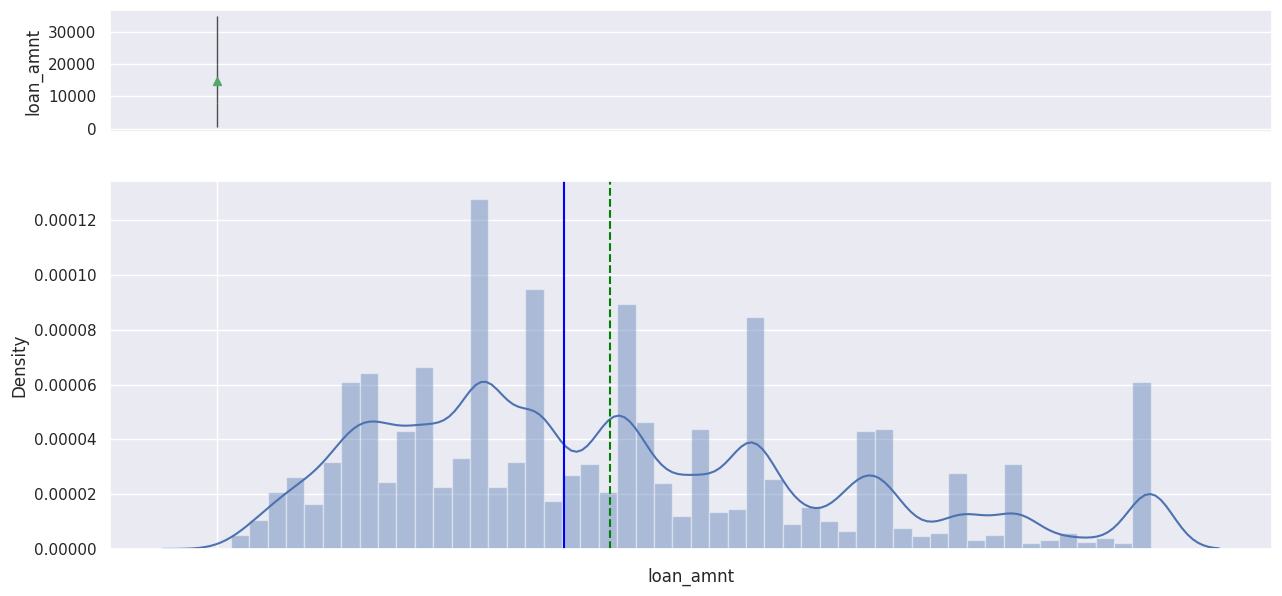

In [23]:
histogram_boxplot(df.loan_amnt)

## revolving_balance

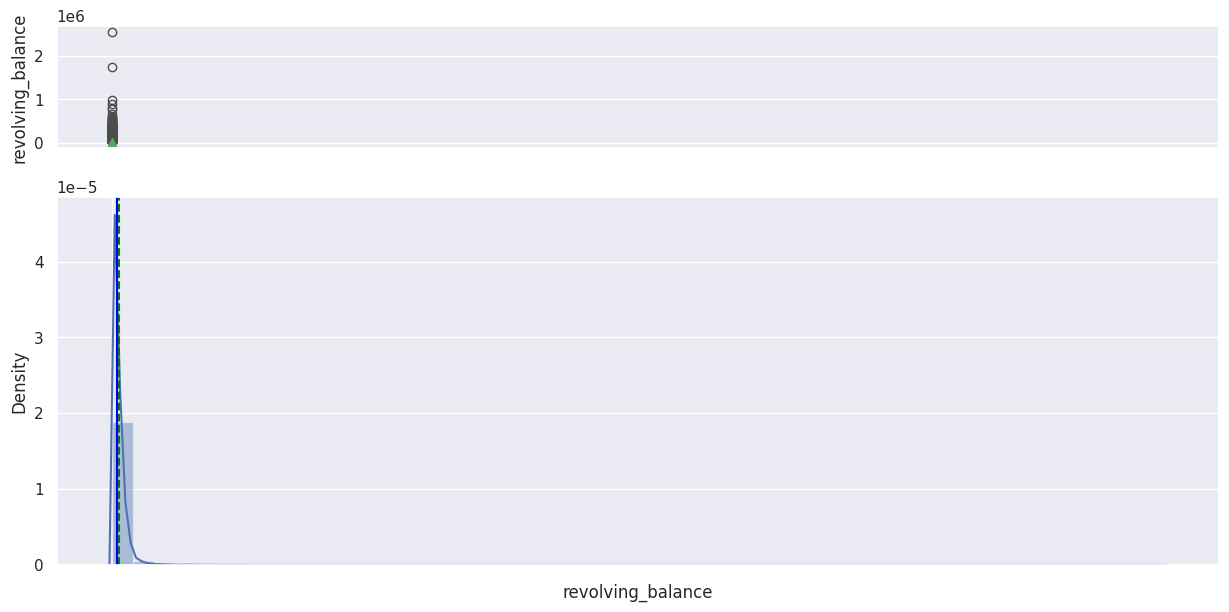

In [24]:
histogram_boxplot(df.revolving_balance)

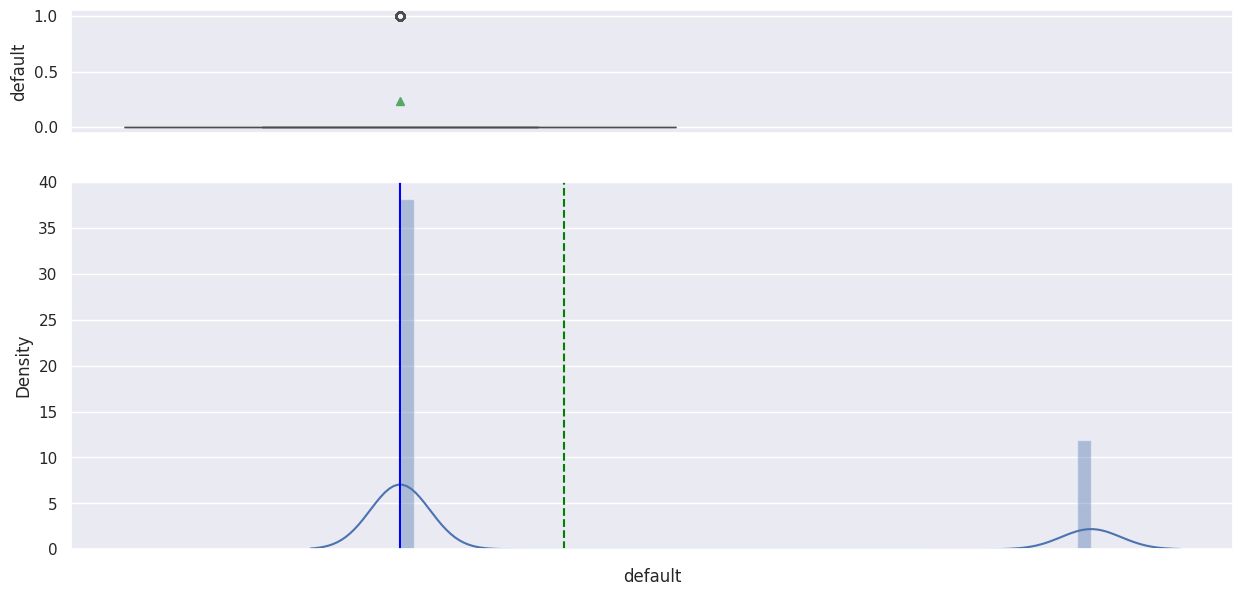

In [25]:
histogram_boxplot(df.default)

In [26]:
df.select_dtypes(include='float').columns

Index(['interest_rate', 'annual_income', 'debt_to_income', 'delinq_2yrs',
       'public_records', 'total_acc', 'interest_receive', 'last_week_pay',
       'total_current_balance', 'total_revolving_limit'],
      dtype='object')

## interest_rate

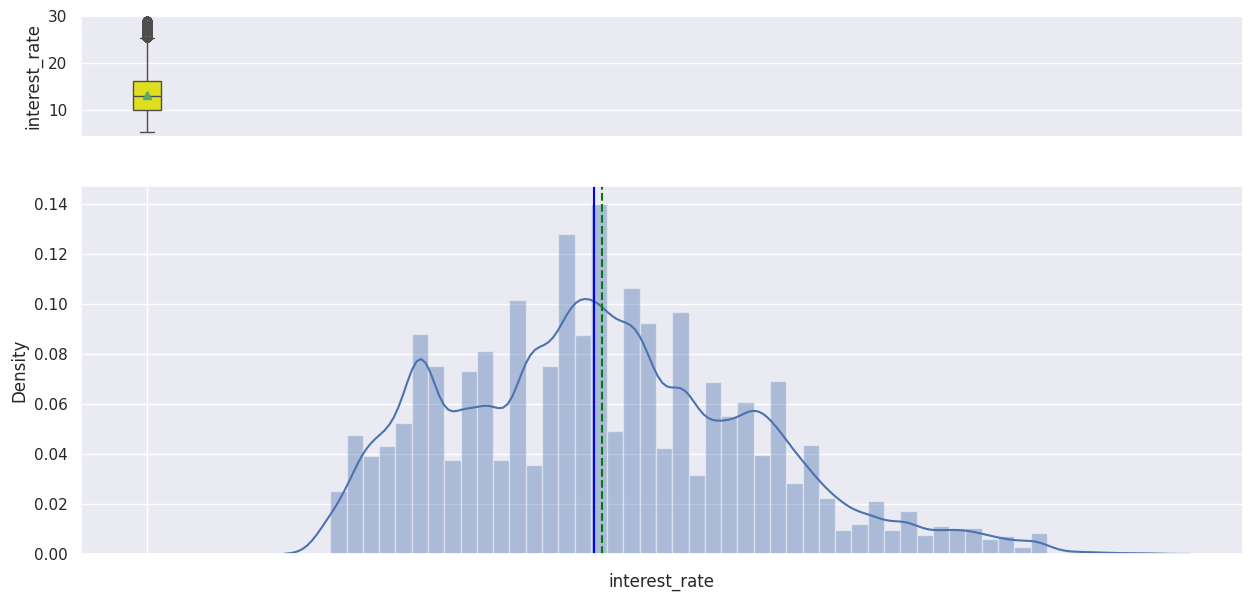

In [27]:
histogram_boxplot(df.interest_rate)

## annual_income

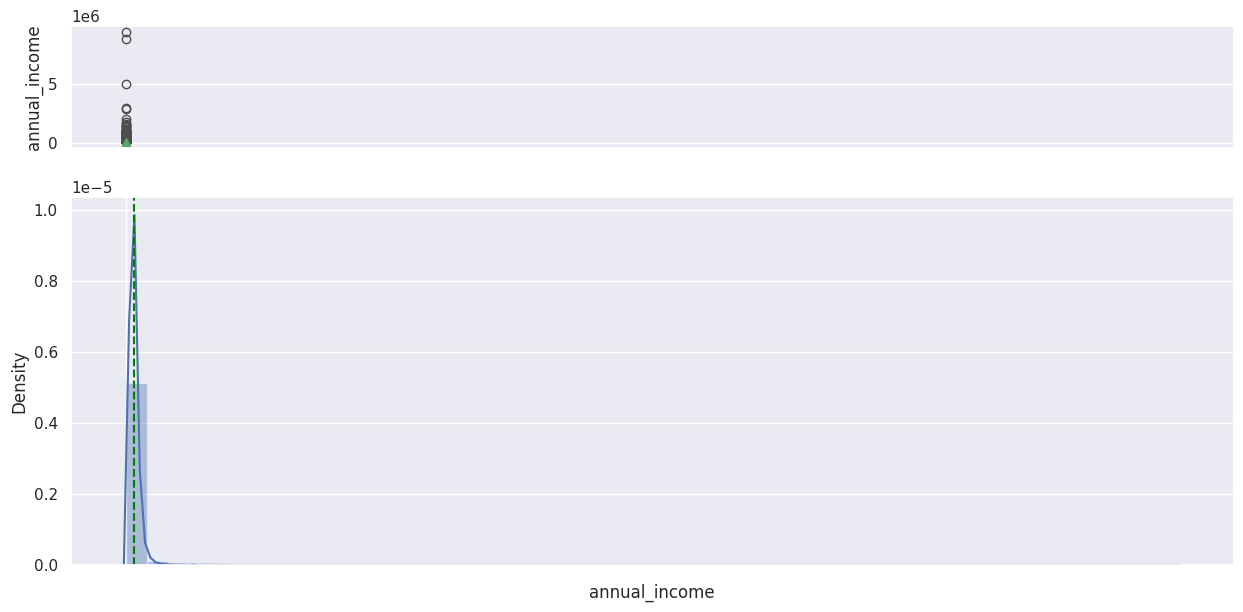

In [28]:
histogram_boxplot(df.annual_income)

## debt_to_income

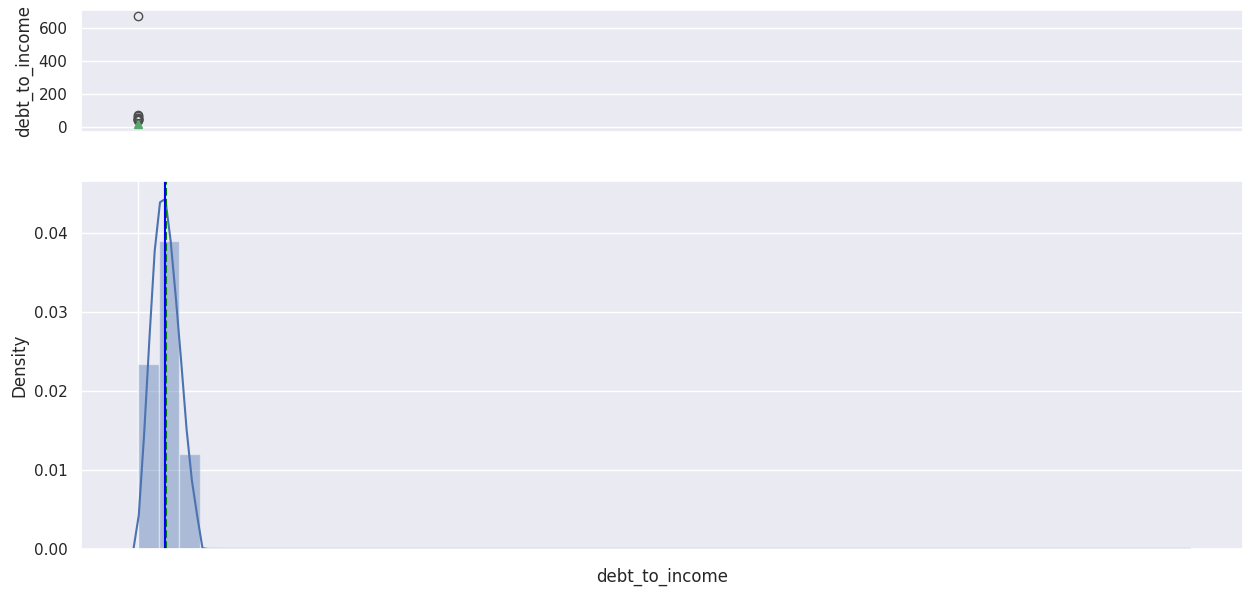

In [29]:
histogram_boxplot(df.debt_to_income)

## delinq_2yrs

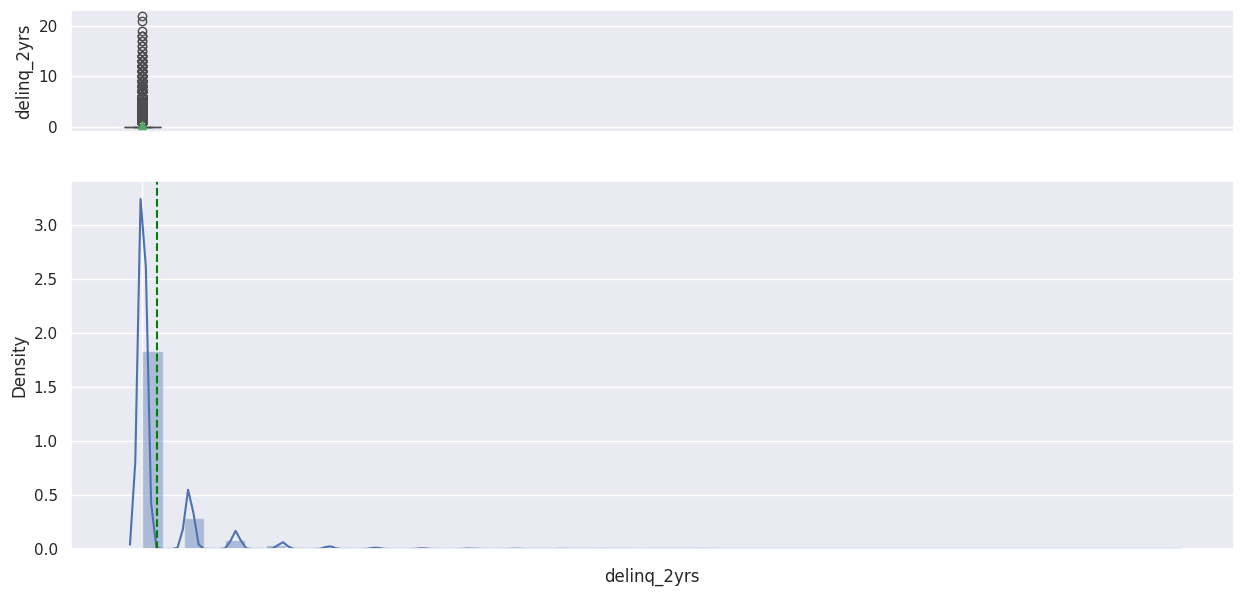

In [30]:
histogram_boxplot(df.delinq_2yrs)

## public_records

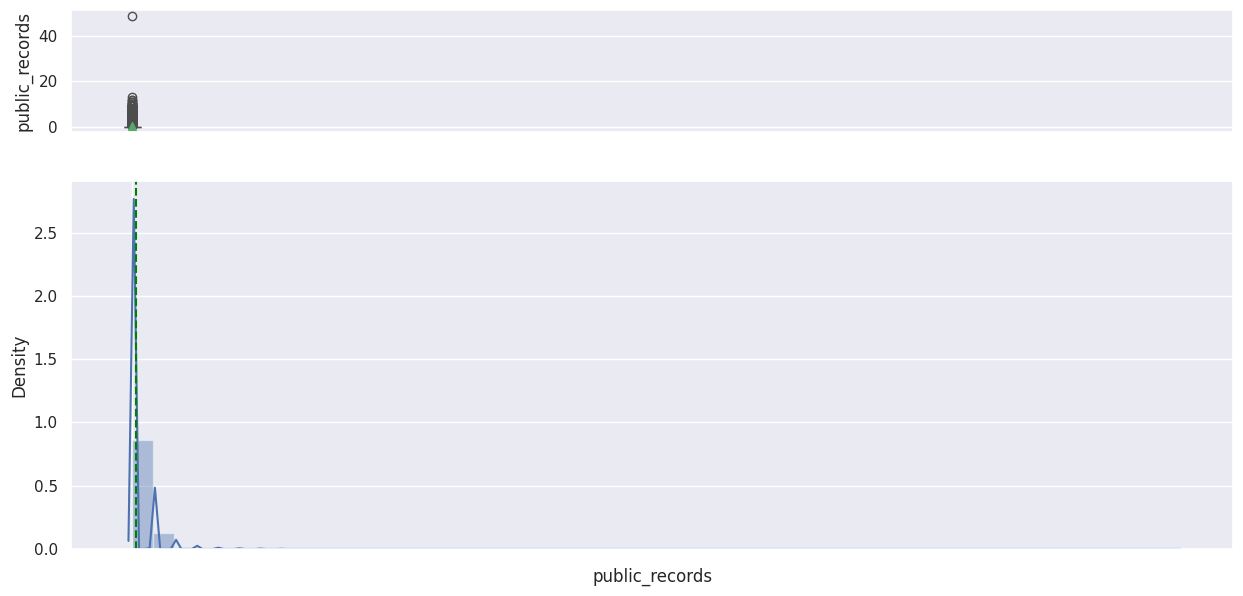

In [31]:
histogram_boxplot(df.public_records)

## total_acc

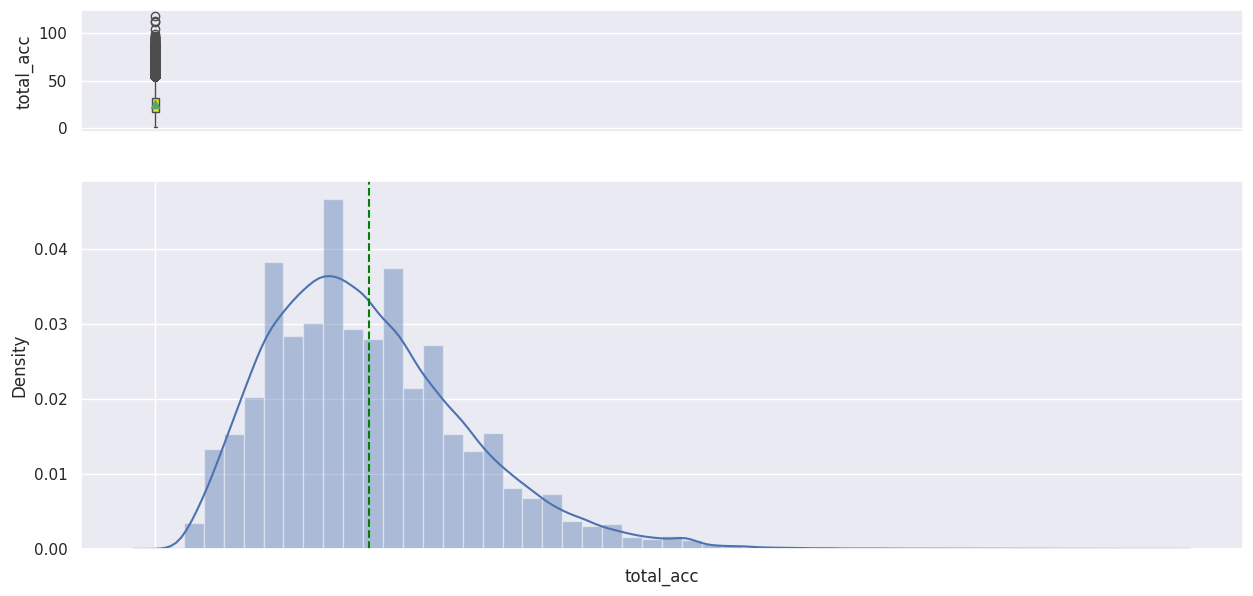

In [32]:
histogram_boxplot(df.total_acc)

## interest_receive

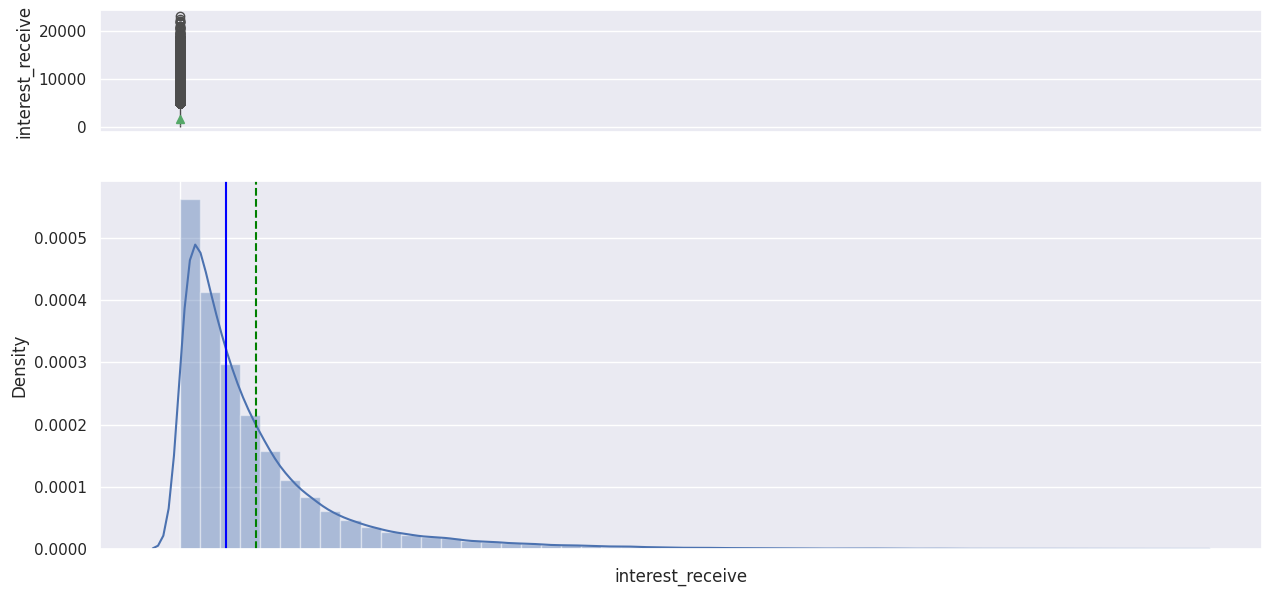

In [33]:
histogram_boxplot(df.interest_receive)

## last_week_pay

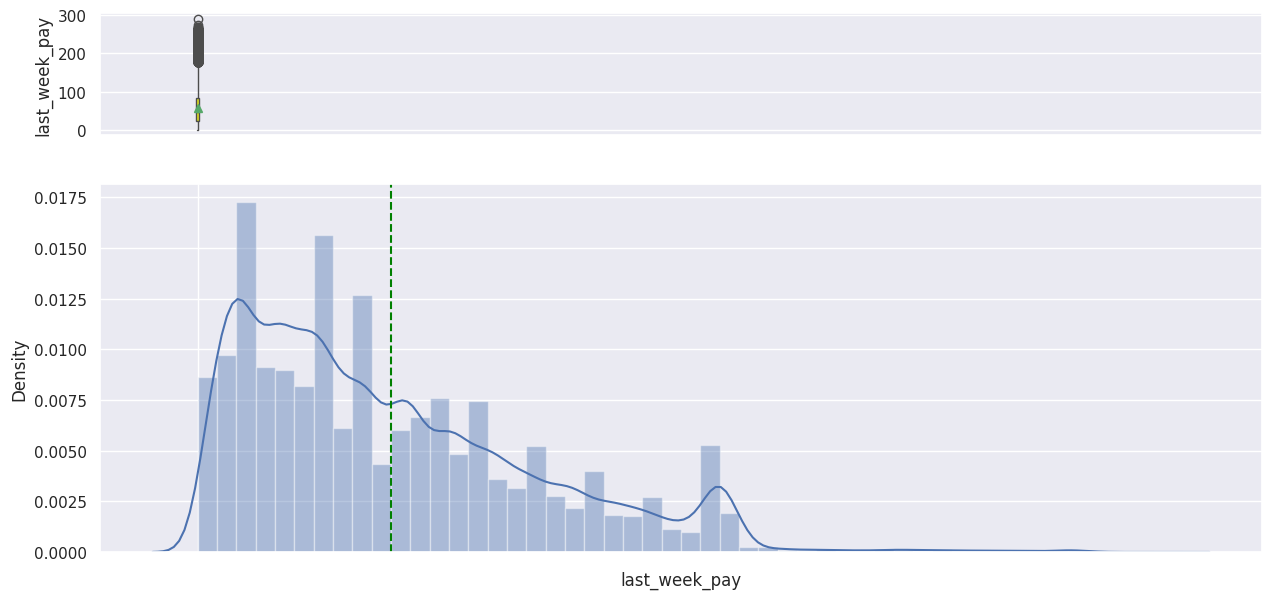

In [34]:
histogram_boxplot(df.last_week_pay)

## total_current_balance

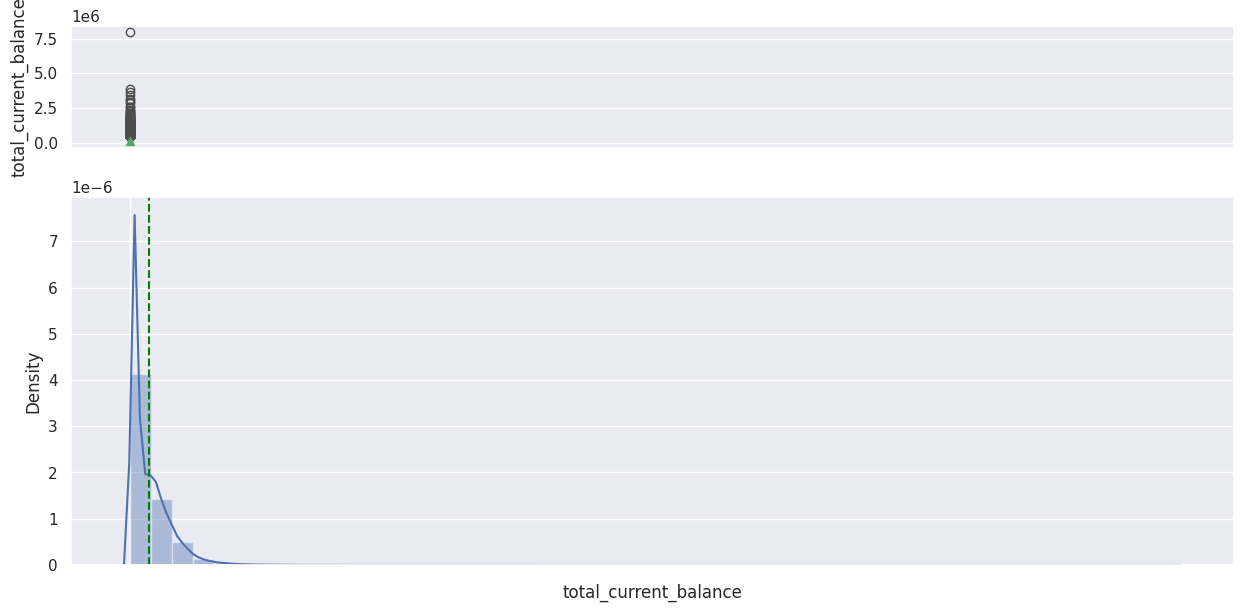

In [35]:
histogram_boxplot(df.total_current_balance)

## total_revolving_limit

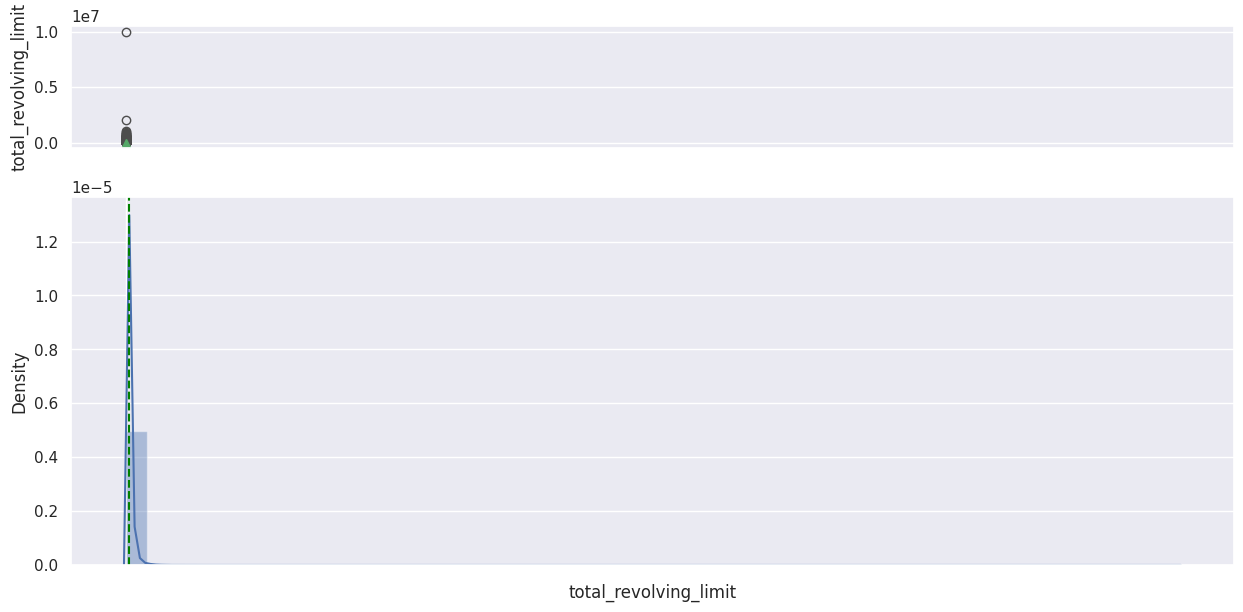

In [36]:
histogram_boxplot(df.total_revolving_limit)

## default

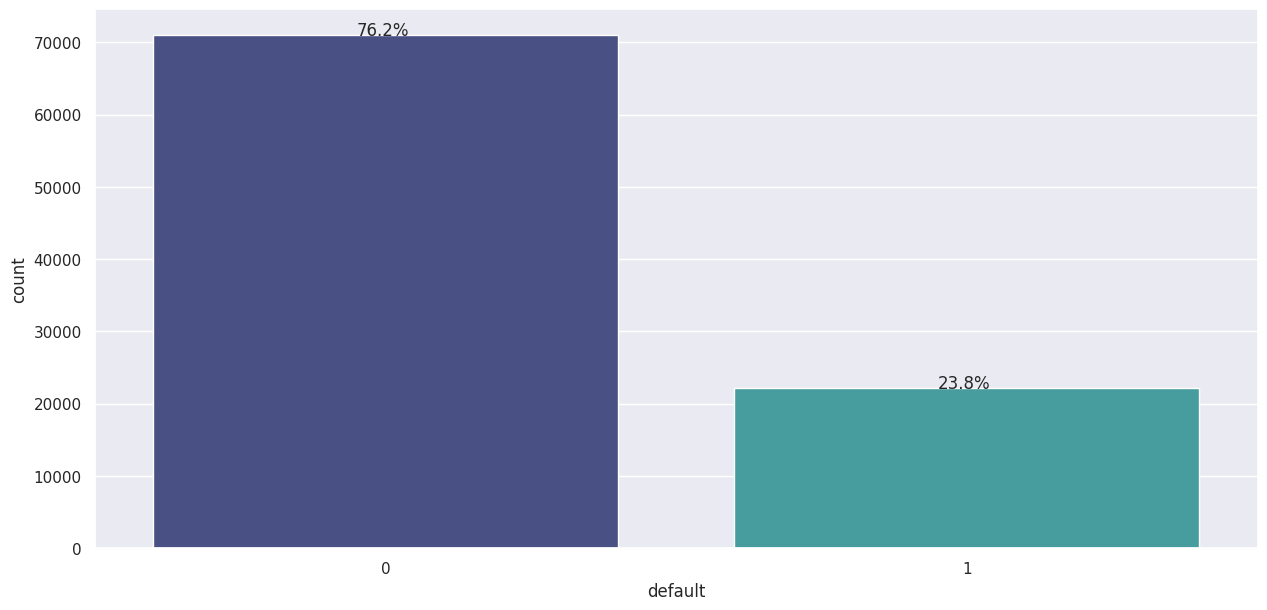

In [37]:
perc_on_bar(df.default)

## default

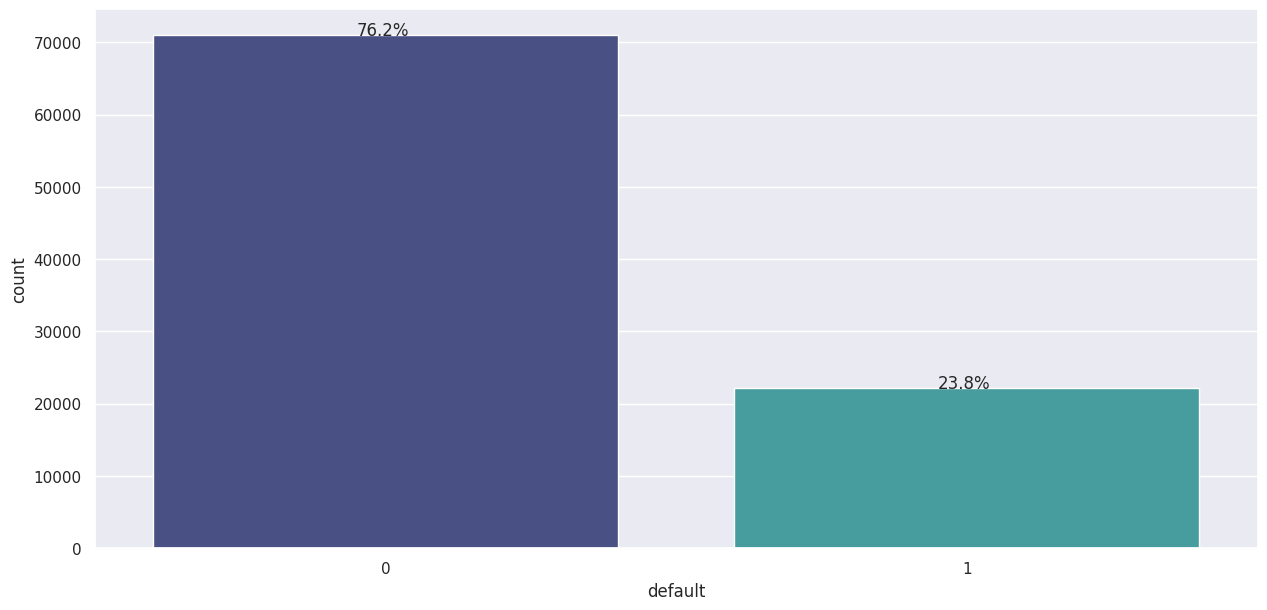

In [42]:
perc_on_bar(df.default)

## delinq_2yrs

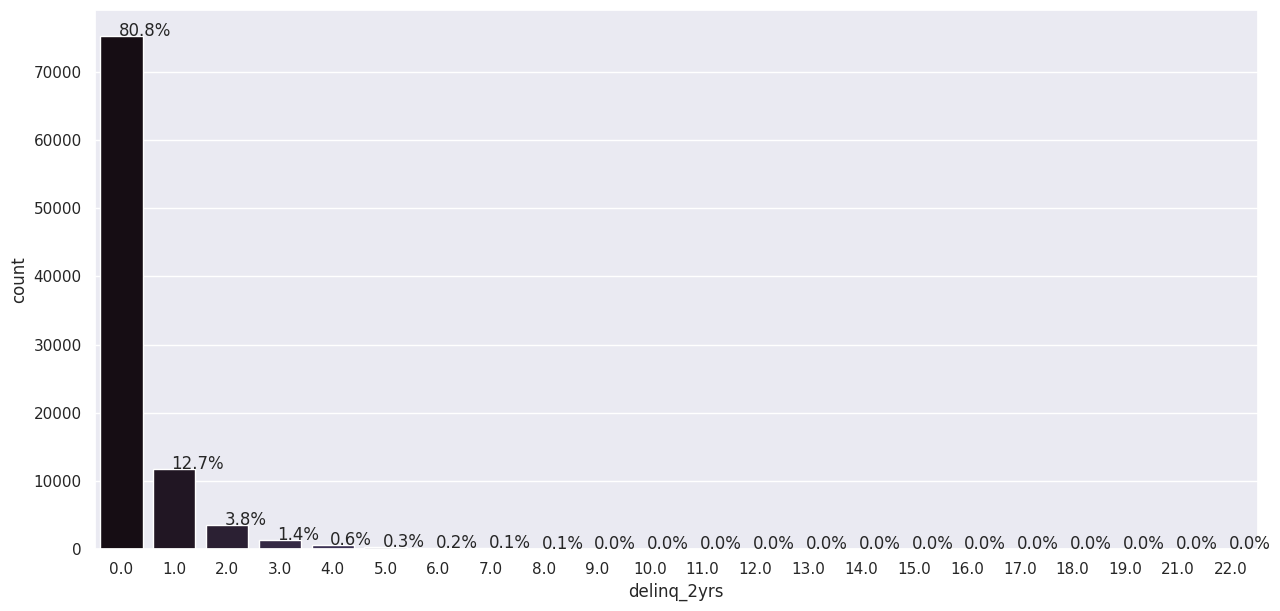

In [43]:
perc_on_bar(df.delinq_2yrs)

## public_records

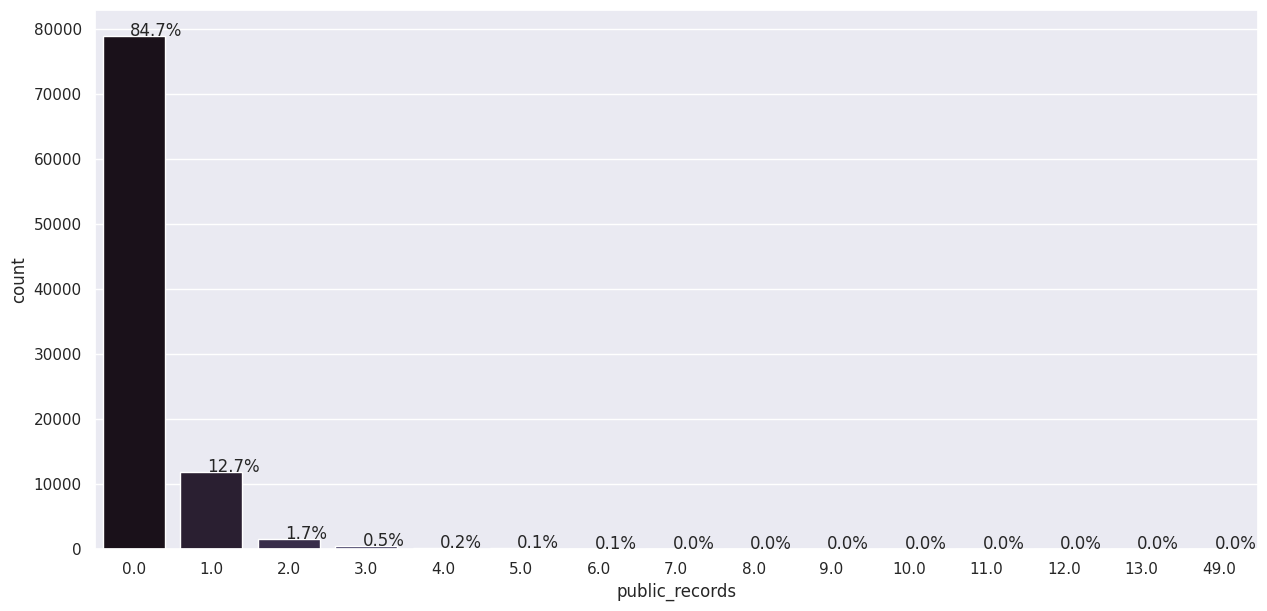

In [44]:
perc_on_bar(df.public_records)

## loan_term

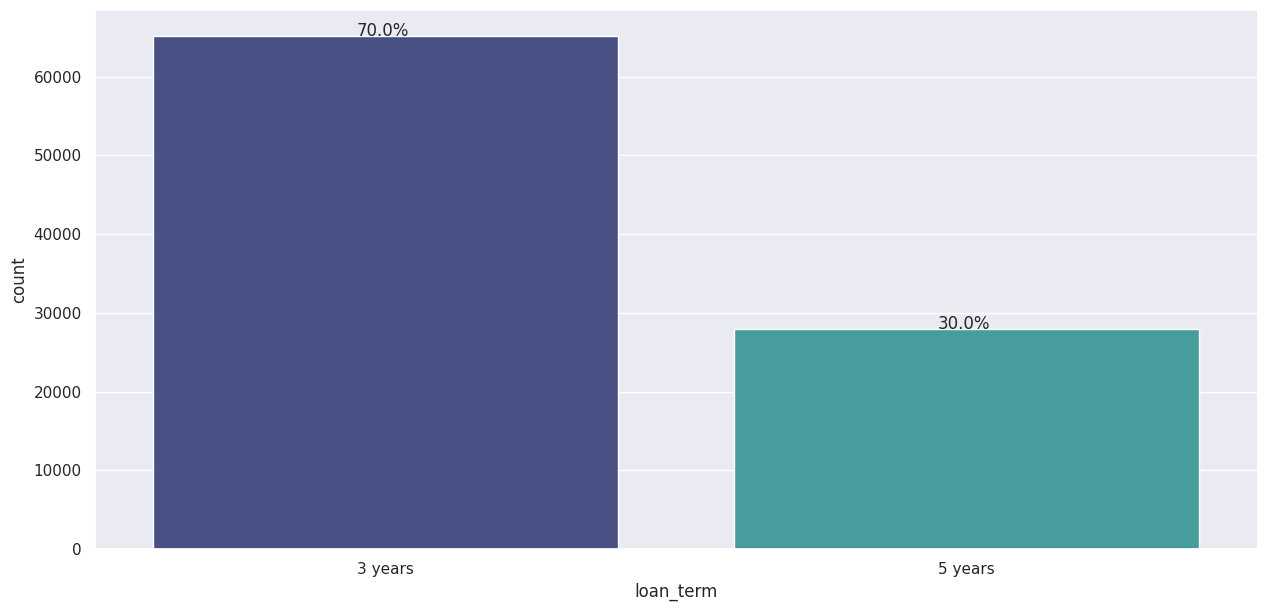

In [45]:
perc_on_bar(df.loan_term)

## loan_grade

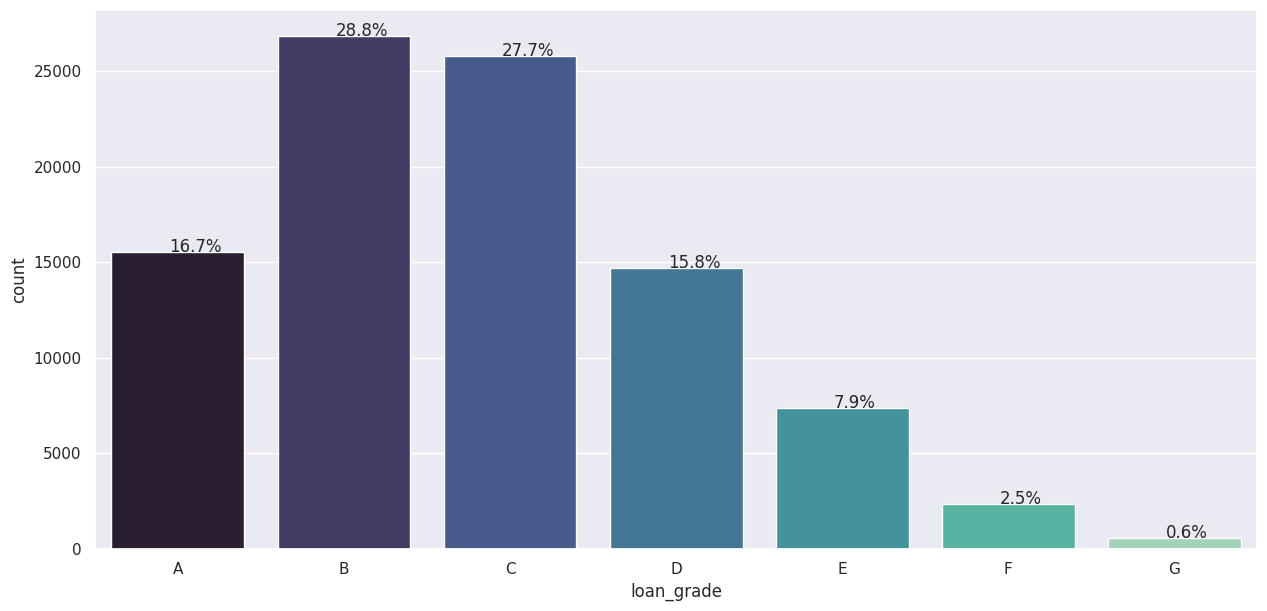

In [46]:
perc_on_bar(df.loan_grade)

## loan_subgrade

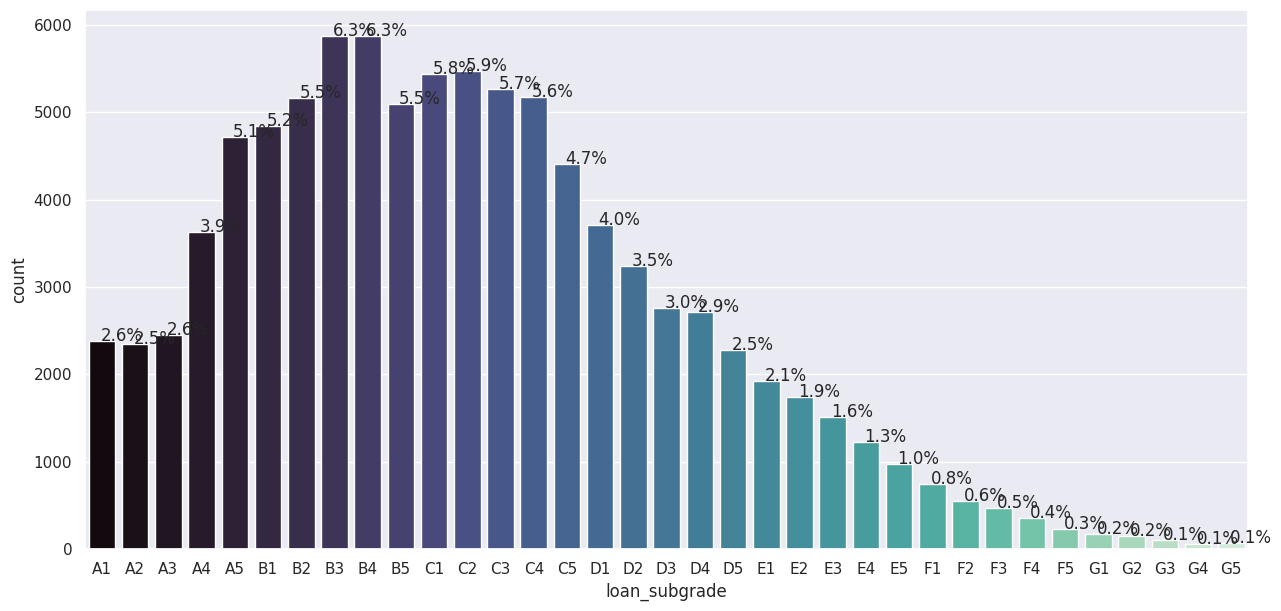

In [47]:
perc_on_bar(df.loan_subgrade)

## job_experience

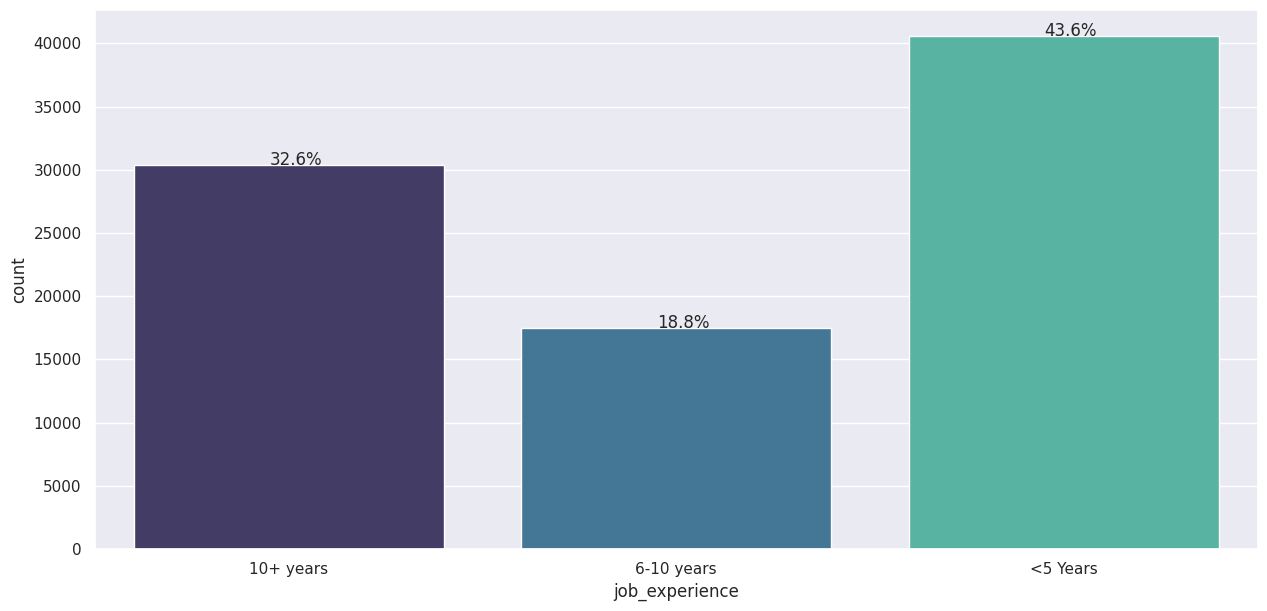

In [48]:
perc_on_bar(df.job_experience)

## home_ownership

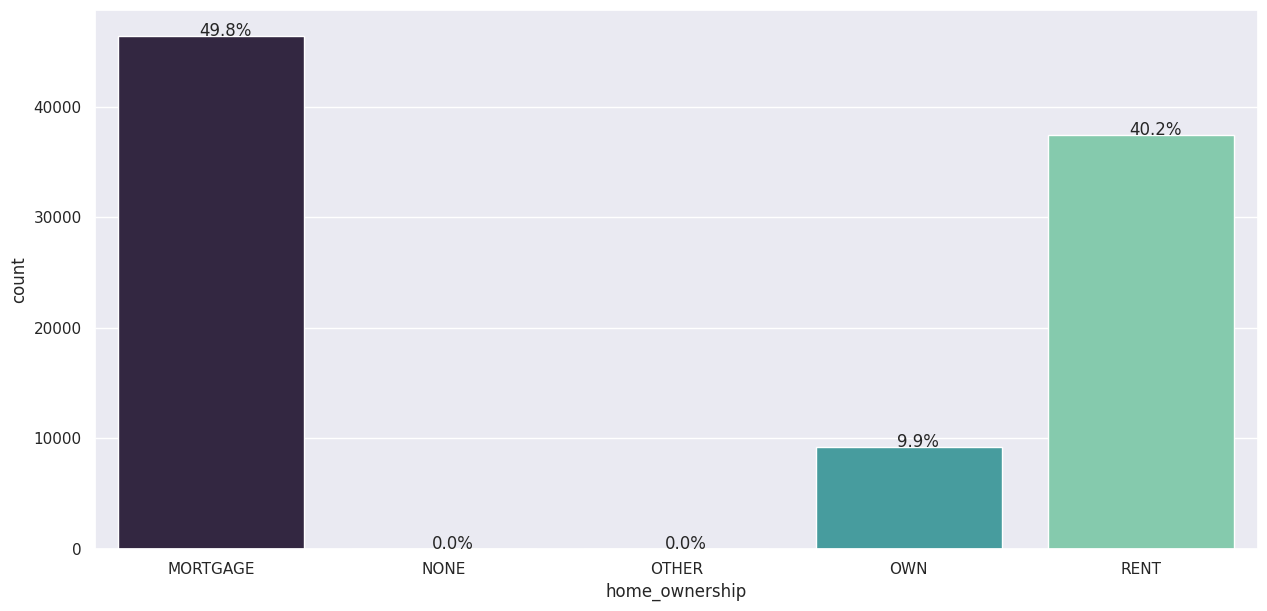

In [49]:
perc_on_bar(df.home_ownership)

In [38]:
# Dataframe summary

def summary(df):
    print(f'data shape: {df.shape}')
    summ = pd.DataFrame(df.dtypes, columns=['Data Type'])
    summ['Missing#'] = df.isna().sum()
    summ['Missing%'] = (df.isna().sum())/len(df)
    summ['Dups'] = df.duplicated().sum()
    summ['Uniques'] = df.nunique().values
    summ['Count'] = df.count().values
    desc = pd.DataFrame(df.describe(include='all').transpose())
    summ['Min'] = desc['min'].values
    summ['Max'] = desc['max'].values
    summ['Average'] = desc['mean'].values
    summ['Standard Deviation'] = desc['std'].values
    summ['First Value'] = df.loc[0].values
    summ['Second Value'] = df.loc[1].values
    summ['Third Value'] = df.loc[2].values

    display(summ)

summary(df)

data shape: (93174, 22)


,Data Type,Missing#,Missing%,Dups,Uniques,Count,Min,Max,Average,Standard Deviation,First Value,Second Value,Third Value
loan_amnt,int64,0,0.000,0,1310,93174,500.000,35000.000,14733.861,8428.185,9000,18000,16000
loan_term,category,0,0.000,0,2,93174,NaN,NaN,NaN,NaN,3 years,3 years,3 years
interest_rate,float64,0,0.000,0,481,93174,5.320,28.990,13.233,4.369,9.170,13.650,7.260
loan_grade,category,0,0.000,0,7,93174,NaN,NaN,NaN,NaN,B,C,A
loan_subgrade,category,0,0.000,0,35,93174,NaN,NaN,NaN,NaN,B2,C1,A4
job_experience,category,4702,0.050,0,3,88472,NaN,NaN,NaN,NaN,<5 Years,<5 Years,<5 Years
home_ownership,category,0,0.000,0,5,93174,NaN,NaN,NaN,NaN,OWN,OWN,MORTGAGE
annual_income,float64,1,0.000,0,8667,93173,1200.000,9500000.000,75028.259,69454.784,85000.000,64000.000,150000.000
income_verification_status,category,0,0.000,0,3,93174,NaN,NaN,NaN,NaN,Not Verified,Verified,Source Verified
loan_purpose,category,0,0.000,0,4,93174,NaN,NaN,NaN,NaN,debt_consolidation,debt_consolidation,debt_consolidation


In [39]:
df.columns

Index(['loan_amnt', 'loan_term', 'interest_rate', 'loan_grade',
       'loan_subgrade', 'job_experience', 'home_ownership', 'annual_income',
       'income_verification_status', 'loan_purpose', 'state_code',
       'debt_to_income', 'delinq_2yrs', 'public_records', 'revolving_balance',
       'total_acc', 'interest_receive', 'application_type', 'last_week_pay',
       'total_current_balance', 'total_revolving_limit', 'default'],
      dtype='object')

In [41]:


df['Default'].value_counts()


KeyError: 'Default'

In [ ]:

num_cols = df.select_dtypes(include=np.number).columns.tolist()


In [ ]:
num_cols

# Plotting all the num_cols for visualising

In [ ]:
def num_summary(dataframe, numerical_col, plot=False):
    #quantiles = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 0.95, 0.99]
    #print(dataframe[numerical_col].describe(quantiles).T)

    if plot:
            fig, axs = plt.subplots(1, 2, figsize=(10, 5))
            plt.subplot(1, 2, 1)
            dataframe[numerical_col].hist(bins=50)
            plt.xlabel(numerical_col)
            plt.title(numerical_col)

            plt.subplot(1, 2, 2)
            sns.boxplot(y=numerical_col, data=dataframe)
            plt.title("Frequency of " + numerical_col)
            plt.xticks(rotation=90)

            plt.show(block=True)

            print("______________________________________________________\n")

for col in num_cols:
    print(col)
    num_summary(df, col, plot=True)


In [ ]:
len(num_cols), len(df.columns)

# Removing the outliers from numerical columns

In [ ]:
na_cols = df.columns[df.isna().all()]
num_na_cols = len(na_cols)
print(f"Number of columns with only NA values: {num_na_cols}")

In [ ]:
df[num_cols].isna().sum()

In [ ]:
to_drop = ["Score_Source_1", "Social_Circle_Default", "Own_House_Age"]
to_drop_2 = ["Client_Occupation", "Score_Source_3"]

In [ ]:


df = df.drop(to_drop_2, axis=1)


In [ ]:
df.head()

In [ ]:
replace_with_mean = ["Child_Count", "Client_Family_Members", "Cleint_City_Rating",
                     "Application_Process_Day", "Application_Process_Hour", "Credit_Bureau"]

In [ ]:
df.head()

In [ ]:
def remove_outliers(df, col):
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5*IQR
  upper_bound = Q3 + 1.5*IQR
  df_out = df[(df[col] > lower_bound) & (df[col] < upper_bound)]
  return df_out

In [ ]:
def remove_missing_values(df, col):
  df = df.dropna(subset=[col])
  return df

In [ ]:
def replace_missing_with_mean(df, col):
  df[col] = df[col].fillna(df[col].mean())
  return df

## The process of cleaning the data-
 - First remove the outliers
 - Fill the NA values with mean wherever possible

 - Remove all missing value columns then.

In [ ]:
for col in replace_with_mean:
  # df = remove_outliers(df, col)
  df = replace_missing_with_mean(df, col)

In [ ]:

df.shape


In [ ]:
for col in df.columns:
  df = remove_missing_values(df, col)

In [ ]:
df.isna().sum()

In [ ]:
df.head()

In [ ]:
df.shape

In [ ]:
df["Default"].value_counts()

In [ ]:
df.isna().sum()

In [ ]:
df.columns

In [ ]:
def balance_dataset(df, target_col):
  class_0 = df[df[target_col] == 0]
  class_1 = df[df[target_col] == 1]

  sample_size = min(len(class_0), len(class_1))

  balanced_df = pd.concat([class_0.sample(sample_size), class_1.sample(sample_size)])

  return balanced_df.sample(frac=1)

df_train = balance_dataset(df, 'Default')

In [ ]:
df_train.shape

In [ ]:
df_train["Default"].value_counts()

Pipeline to the model

In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_curve, roc_auc_score, confusion_matrix, classification_report
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

# Function to handle full pipeline with one-hot encoding
def random_forest_pipeline(df, target_column, categorical_columns):
    # Step 1: Data preparation
    X = df.drop(columns=[target_column])  # Features
    y = df[target_column]  # Target

    # Step 2: Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # Step 3: Preprocessing - One Hot Encoding for categorical columns
    # Define column transformer to one-hot encode categorical columns and scale numerical ones
    preprocessor = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(), categorical_columns),
            ('num', StandardScaler(), [col for col in X.columns if col not in categorical_columns])
        ]
    )

    # Step 4: Define Random Forest pipeline
    rf_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(random_state=42))
    ])

    # Step 5: Cross-validation
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cross_val_scores = cross_val_score(rf_pipeline, X_train, y_train, cv=cv, scoring='accuracy')

    print(f"Cross-Validation Accuracy Scores: {cross_val_scores}")
    print(f"Mean Cross-Validation Accuracy: {cross_val_scores.mean()}")

    # Step 6: Train the pipeline model
    rf_pipeline.fit(X_train, y_train)

    # Step 7: Predictions on the test set
    y_pred = rf_pipeline.predict(X_test)

    # Step 8: Model Evaluation
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Test Accuracy: {accuracy}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    print("\nConfusion Matrix:")
    conf_matrix = confusion_matrix(y_test, y_pred)
    print(conf_matrix)

    # Step 9: ROC Curve and AUC
    y_pred_proba = rf_pipeline.predict_proba(X_test)[:, 1]  # Probability estimates for the positive class
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    # Plotting ROC curve
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
    plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Receiver Operating Characteristic (ROC) Curve")
    plt.legend()
    plt.show()

    # Step 10: Function to predict on new data
    def predict_new_data(new_data):
        return rf_pipeline.predict(new_data)

    # Return the trained model and prediction function
    return rf_pipeline, predict_new_data

# Example usage of the function
# df = pd.read_csv('your_data.csv')  # Load your dataset
# categorical_columns = ['col1', 'col2']  # Specify your categorical columns
# rf_model, predict_new_data = random_forest_pipeline(df, 'target', categorical_columns)  # Replace 'target' with your actual target column

# Making predictions on new data
# new_data = pd.DataFrame(...)  # Load or create new data to predict on
# predictions = predict_new_data(new_data)
# print(predictions)



In [ ]:


import numpy as np
cat_cols = df_train.select_dtypes(exclude=np.number).columns.tolist()
print(cat_cols)


# Random Forest Pipeline
 - Only for Random Forest classifier model

In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_curve, roc_auc_score, confusion_matrix, classification_report
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

# Function to handle full pipeline with type consistency and one-hot encoding
def random_forest_pipeline_2(df, target_column, categorical_columns):
    # Step 1: Data preparation
    # Ensure that all categorical columns have consistent string data types
    for col in categorical_columns:
        df[col] = df[col].astype(str)

    X = df.drop(columns=[target_column])  # Features
    y = df[target_column]  # Target

    # Step 2: Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # Step 3: Preprocessing - One Hot Encoding for categorical columns
    # Define column transformer to one-hot encode categorical columns and scale numerical ones
    preprocessor = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_columns),  # One-hot encoding for categorical columns
            ('num', StandardScaler(), [col for col in X.columns if col not in categorical_columns])  # Scaling numerical columns
        ]
    )

    # Step 4: Define Random Forest pipeline
    rf_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(random_state=42))
    ])

    # Step 5: Cross-validation
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cross_val_scores = cross_val_score(rf_pipeline, X_train, y_train, cv=cv, scoring='accuracy')

    print(f"Cross-Validation Accuracy Scores: {cross_val_scores}")
    print(f"Mean Cross-Validation Accuracy: {cross_val_scores.mean()}")

    # Step 6: Train the pipeline model
    rf_pipeline.fit(X_train, y_train)

    # Step 7: Predictions on the test set
    y_pred = rf_pipeline.predict(X_test)

    # Step 8: Model Evaluation
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Test Accuracy: {accuracy}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    print("\nConfusion Matrix:")
    conf_matrix = confusion_matrix(y_test, y_pred)
    print(conf_matrix)

    # Step 9: ROC Curve and AUC
    y_pred_proba = rf_pipeline.predict_proba(X_test)[:, 1]  # Probability estimates for the positive class
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    # Plotting ROC curve
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
    plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Receiver Operating Characteristic (ROC) Curve")
    plt.legend()
    plt.show()

    # Step 10: Function to predict on new data
    def predict_new_data(new_data):
        # Convert categorical columns to strings before prediction
        for col in categorical_columns:
            new_data[col] = new_data[col].astype(str)
        return rf_pipeline.predict(new_data)

    # Return the trained model and prediction function
    return rf_pipeline, predict_new_data, y_pred

# Example usage of the function
# df = pd.read_csv('your_data.csv')  # Load your dataset
# categorical_columns = ['col1', 'col2']  # Specify your categorical columns
# rf_model, predict_new_data = random_forest_pipeline(df, 'target', categorical_columns)  # Replace 'target' with your actual target column

# Making predictions on new data
# new_data = pd.DataFrame(...)  # Load or create new data to predict on
# predictions = predict_new_data(new_data)
# print(predictions)


# Classsification Pipeline
- Trying 3 different models to choose best model

In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_curve, roc_auc_score, confusion_matrix, classification_report
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

# Function to handle full pipeline with type consistency, one-hot encoding, and multiple model options
def classification_pipeline(df, target_column, categorical_columns, model):
    # Step 1: Data preparation
    # Ensure that all categorical columns have consistent string data types
    for col in categorical_columns:
        df[col] = df[col].astype(str)

    X = df.drop(columns=[target_column])  # Features
    y = df[target_column]  # Target

    # Step 2: Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # Step 3: Preprocessing - One Hot Encoding for categorical columns
    # Define column transformer to one-hot encode categorical columns and scale numerical ones
    preprocessor = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_columns),  # One-hot encoding for categorical columns
            ('num', StandardScaler(), [col for col in X.columns if col not in categorical_columns])  # Scaling numerical columns
        ]
    )

    # Step 4: Define the classification pipeline with the selected model
    clf_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    # Step 5: Cross-validation
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cross_val_scores = cross_val_score(clf_pipeline, X_train, y_train, cv=cv, scoring='accuracy')

    print(f"Cross-Validation Accuracy Scores: {cross_val_scores}")
    print(f"Mean Cross-Validation Accuracy: {cross_val_scores.mean()}")

    # Step 6: Train the pipeline model
    clf_pipeline.fit(X_train, y_train)

    # Step 7: Predictions on the test set
    y_pred = clf_pipeline.predict(X_test)

    # Step 8: Model Evaluation
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Test Accuracy: {accuracy}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    print("\nConfusion Matrix:")
    conf_matrix = confusion_matrix(y_test, y_pred)
    print(conf_matrix)

    # Step 9: ROC Curve and AUC
    y_pred_proba = clf_pipeline.predict_proba(X_test)[:, 1]  # Probability estimates for the positive class
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    # Plotting ROC curve
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
    plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Receiver Operating Characteristic (ROC) Curve")
    plt.legend()
    plt.show()

    # Step 10: Function to predict on new data
    def predict_new_data(new_data):
        # Convert categorical columns to strings before prediction
        for col in categorical_columns:
            new_data[col] = new_data[col].astype(str)
        return clf_pipeline.predict(new_data)

    # Return the trained model and prediction function
    return clf_pipeline, predict_new_data, y_pred, y_test



In [ ]:
# Using RandomForest
rf_model, predict_new_data_rf, rf_predictions, y_test = classification_pipeline(df_train, 'Default', cat_cols, RandomForestClassifier(random_state=42))


In [ ]:
# Using Logistic Regression
lr_model, predict_new_data_lr, lr_predictions, y_test = classification_pipeline(df_train, 'Default', cat_cols, LogisticRegression(max_iter=1000))

In [ ]:
# Using Gradient Boosting
gb_model, predict_new_data_gb, gb_predictions, y_test = classification_pipeline(df_train, 'Default', cat_cols, GradientBoostingClassifier(random_state=42))

In [ ]:

def evaluate_model(model, y_test, y_pred):

    accuracy = accuracy_score(y_test, y_pred)
    return accuracy

In [ ]:
def compare_models(y_test, gb_predictions, lr_predictions, rf_predictions):
  models = [gb_model, lr_model, rf_model]
  predictions = [gb_predictions, lr_predictions, rf_predictions]
  accuracies = []

  for model, pred in zip(models, predictions):
    accuracies.append(evaluate_model(model, y_test, pred))
    return accuracies

In [ ]:
# Plotting the accuracies
accuracies = compare_models(y_test, gb_predictions, lr_predictions, rf_predictions)
models = ['Gradient Boosting', 'Logistic Regression', 'Random Forest']
plt.figure(figsize=(10, 6))
plt.bar(models, accuracies, color=['blue', 'green', 'orange'])
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Model Accuracies Comparison Before Tuning')
plt.show()

In [ ]:
X = df_train.drop(columns=['Default'])
y = df_train['Default']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
# Tuning rf forest classifier

from sklearn.model_selection import GridSearchCV

def tune_random_forest(X_train, y_train):
    # Define the parameter grid for grid search
    param_grid = {
        'classifier__n_estimators': [200, 300, 500],
        'classifier__max_depth': [None, 20, 30],
        'classifier__min_samples_split': [5, 10],
        'classifier__min_samples_leaf': [2, 4],
        'classifier__bootstrap': [True, False]
    }


    rf = rf_model
    grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=1, verbose=2)
    grid_search.fit(X_train, y_train)

    print("Best parameters for Random Forest:", grid_search.best_params_)
    print("Best cross-validation accuracy:", grid_search.best_score_)

    return grid_search.best_estimator_


In [ ]:
# For logistics Regression



def tune_logistic_regression(X_train, y_train):
    param_grid = {
        'classifier__C': [0.1, 1, 10, 100],
        'classifier__solver': ['newton-cg', 'lbfgs', 'liblinear'],
        'classifier__penalty': ['l2'],
        'classifier__max_iter': [200, 500]
    }
    lr = lr_model
    grid_search = GridSearchCV(estimator=lr, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=1, verbose=2)
    grid_search.fit(X_train, y_train)

    print("Best parameters for Logistic Regression:", grid_search.best_params_)
    print("Best cross-validation accuracy:", grid_search.best_score_)

    return grid_search.best_estimator_


In [ ]:
# For GradientBoostingClassifier

def tune_gradient_boosting(X_train, y_train):
    param_grid = {
        'classifier__n_estimators': [200, 300, 500],
        'classifier__learning_rate': [0.1, 0.05],
        'classifier__max_depth': [5, 8],
        'classifier__min_samples_split': [5, 10],
        'classifier__min_samples_leaf': [2, 4],
        'classifier__subsample': [1.0]
    }
    gb = gb_model
    grid_search = GridSearchCV(estimator=gb, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=1, verbose=2)
    grid_search.fit(X_train, y_train)

    print("Best parameters for Gradient Boosting:", grid_search.best_params_)
    print("Best cross-validation accuracy:", grid_search.best_score_)

    return grid_search.best_estimator_


## From Rf classifier
Best parameters for Random Forest: {'classifier__bootstrap': True, 'classifier__max_depth': 30, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}
Best cross-validation accuracy: 0.6575842696629214

## From lr classifier
Best parameters for Logistic Regression: {'classifier__C': 0.1, 'classifier__max_iter': 200, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}
Best cross-validation accuracy: 0.6394535240040857


## From Gradint Booster
Best parameters for Gradient Boosting: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 5, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 300, 'classifier__subsample': 1.0}
Best cross-validation accuracy: 0.628140960163432



## Uncomment these lines when you need to tune the model as its time taking

In [ ]:
# tune_random_forest(X_train, y_train)

In [ ]:
# tune_logistic_regression(X_train, y_train)

In [ ]:
# tune_gradient_boosting(X_train, y_train)

# Comparison of accuracies after tuning the models
- It's decreased actually

In [ ]:
best_cv_accuracy = [0.628140960163432, 0.6394535240040857, 0.6575842696629214]

plt.figure(figsize=(10, 6))
plt.bar(models, best_cv_accuracy, color=['blue', 'green', 'orange'])
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Comparison Of Best Cross Validation Accuracies')
plt.show()


# Put Best params model in classification pipeline to get report over it


In [ ]:

rf_tuned_model, predict_new_data_rf_tuned, rf_predictions_tuned, y_test = classification_pipeline(df_train, 'Default', cat_cols, RandomForestClassifier(random_state=42,
                                                                                                                                                        n_estimators=100,
                                                                                                                                                        max_depth= 30,
                                                                                                                                                        min_samples_leaf= 1,
                                                                                                                                                        min_samples_split=5))

In [ ]:
gb_tuned_model, predict_new_data_gb_tuned, gb_predictions_tuned, y_test = classification_pipeline(df_train,
                                                                                                  'Default',
                                                                                                  cat_cols,
                                                                                                  GradientBoostingClassifier(random_state=42,
                                                                                                                                     n_estimators=300,
                                                                                                                                     learning_rate=0.1,
                                                                                                                                     max_depth=5,
                                                                                                                                     min_samples_leaf=2))


In [ ]:
lr_tuned_model, predict_new_data_lr_tuned, lr_predictions_tuned, y_test = classification_pipeline(df_train,
                                                                                                  'Default',
                                                                                                  cat_cols,
                                                                                                  LogisticRegression(max_iter=1000,
                                                                                                                     C=0.1,
                                                                                                                     penalty='l2',
                                                                                                                     solver='liblinear'))

In [ ]:
test_accuracies = []
tuned_models = [gb_tuned_model, lr_tuned_model, rf_tuned_model]
tuned_predictions = [gb_predictions_tuned, lr_predictions_tuned, rf_predictions_tuned]

for model, pred in zip(tuned_models, tuned_predictions):
  test_accuracies.append(evaluate_model(model, y_test, pred))



In [ ]:
plt.figure(figsize=(15, 6))

plt.subplot(1,2,1)
plt.bar(models, accuracies, color=['blue', 'green', 'orange'])
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Model Test Accuracies Comparison Before Tuning')

plt.subplot(1,2,2)
plt.bar(models, test_accuracies, color=['blue', 'green', 'orange'])
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Model Test Accuracies Comparison After Tuning')



# Saving The Model

In [ ]:
# import pickle

# def save_model(model, filename):
#   with open(filename, 'wb') as file:
#     pickle.dump(model, file)

In [ ]:
# save_model(model, 'model.pkl')

In [ ]:
# import pandas as pd

# def save_predictions_to_csv(predictions, filename):
#   df = pd.DataFrame({'Predictions': predictions}, index=range(len(predictions)))
#   df.to_csv(filename, index=False)

In [ ]:
# save_predictions_to_csv(predictions, 'predictions.csv')

In [ ]:
# save_predictions_to_csv_2(test_ds, 'test.csv')

In [ ]:
# test_ds = df_train.drop(columns=['Default'])

In [ ]:
# test_ds.to_csv('test_update.csv', index=False)